# FULCRUM — Exploratory Data Analysis

**Dataset:** UCI Bank Marketing, `bank-additional-full.csv` (41,188 rows, 21 columns)

This notebook does not catalog the dataset column by column. Every chart below
exists to answer a specific targeting or operations question about the
campaign — if a chart doesn't change a decision, it isn't here. See
[`docs/data_dictionary.md`](../docs/data_dictionary.md) for the full column
reference, including the `duration` leakage warning (excluded from every
chart here since it's post-call information).

**Contents**
1. Data quality — issues found and handling decisions
2. Target rate: overall and by every categorical
3. Campaign contacts (`campaign`) vs outcome
4. Prior-contact behavior (`pdays`, `previous`) including the 999 sentinel
5. Macro-economic conditions vs outcome over time
6. What this means for targeting

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

from data.load import load_bank_additional

# --- palette (validated categorical order — see dataviz skill) ---
BLUE, ORANGE, AQUA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": AXIS,
    "axes.labelcolor": INK2,
    "text.color": INK,
    "xtick.color": INK2,
    "ytick.color": INK2,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10.5,
    "figure.dpi": 110,
})

def pct_axis(ax, axis="y"):
    fmt = mticker.PercentFormatter(xmax=1, decimals=0)
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)

def bar_with_labels(ax, x, height, color=BLUE, fmt="{:.1%}", label_offset=0.006):
    bars = ax.bar(x, height, color=color, width=0.62, zorder=3)
    for b, h in zip(bars, height):
        ax.text(b.get_x() + b.get_width() / 2, h + label_offset, fmt.format(h),
                 ha="center", va="bottom", fontsize=9, color=INK)
    return bars

def baseline_ref(ax, y, label):
    ax.axhline(y, color=MUTED, linewidth=1, linestyle="--", zorder=2)
    ax.text(ax.get_xlim()[1], y, f"  {label}", va="center", ha="left",
             fontsize=8.5, color=MUTED, clip_on=False)

pd.set_option("display.width", 120)

In [2]:
df_raw = load_bank_additional("../data/raw/bank-additional-full.csv")
OVERALL_RATE = (df_raw["y"] == "yes").mean()
print(f"{len(df_raw):,} rows loaded. Overall subscription rate: {OVERALL_RATE:.2%}")

41,188 rows loaded. Overall subscription rate: 11.27%


## 1. Data quality — issues found and handling decisions

Each row: what's wrong, how big it is, what we're doing about it, and why.
Decisions are implemented in the code cell right after this table so the rest
of the notebook runs on the corrected frame (`df`), not the raw load.

| # | Issue | Evidence | Decision | Justification |
|---|-------|----------|----------|----------------|
| 1 | `default` has a very high `unknown` rate | 8,597 rows / **20.87%** | Keep `unknown` as its own category, do not impute or drop | At 1 in 5 rows, dropping destroys a fifth of the data; imputing a mode manufactures a "no" that we don't actually know. Missingness itself may be informative (clients who won't disclose default status may differ systematically). |
| 2 | `education`, `job`, `marital`, `housing`, `loan` also have `unknown` values | 1,731 (4.20%) / 330 (0.80%) / 80 (0.19%) / 990 (2.40%) / 990 (2.40%) | Same as above — keep as an explicit category | Consistency with #1; volumes are small enough that dropping wouldn't hurt, but a mixed policy (impute some, drop others) makes results harder to explain to a hiring manager or a stakeholder. |
| 3 | `pdays` uses **999** as a sentinel for "never contacted before" | 39,673 / **96.32%** of rows | Do not feed `pdays` to any model or chart as a raw number. Derive `was_contacted_before = pdays != 999`, and only compute `pdays` statistics (mean, buckets) on the 1,515-row subset where it's real | 999 sitting next to a real range of 0–27 days is not an outlier, it's a different variable wearing the same column. Any raw mean/std/scaling on `pdays` is meaningless until this is split out. |
| 4 | 12 exact duplicate rows | 12 / 41,188 (0.03%) | Drop them | Fully identical rows across all 21 columns (including the target) are almost certainly a re-extraction artifact, not 12 genuinely identical clients. Volume is negligible either way. |
| 5 | No year or date field — only `month` and `day_of_week`, and **`month` values repeat across multiple years** | Confirmed below: `emp.var.rate` (a quarterly macro indicator) changes only 11 times across all 41,188 rows and forms contiguous blocks — consistent with the file being chronologically sorted across ~3 years, with month labels cycling | Use **row order** as a time proxy for any trend-over-time chart. Never treat `month` alone as a time axis. | Without row order as a stand-in, the macro-vs-time chart the brief asks for is impossible to build correctly — grouping by `month` label alone would silently merge different years into one bucket. |
| 6 | `contact` channel is confounded with time period | Telephone contacts span row-index 0–41,171 (mean row 10,009); cellular contacts are concentrated later, row-index 12,357–41,187 (mean row 26,684) | Treat the raw `contact`-vs-outcome comparison as descriptive only, not causal | Cellular's higher raw success rate could be a channel effect, or it could just be that cellular-heavy periods overlap the post-2008 downturn when everyone was more receptive (see §5). Recommending a channel switch off the raw comparison would be a confound, not a finding. |
| 7 | `campaign` has a long right tail | Max 56 contacts in a single campaign to one client; 1,094 rows (2.7%) at 10+ contacts | Keep raw for EDA (the tail *is* the finding, see §3); cap or log-transform before feeding to a distance- or scale-sensitive model | The shape of the drop-off is the business signal here — compressing it in EDA would hide the finding this chart exists to show. |
| 8 | `age` has a few extreme values | Max 98; 3 rows ≥ 95 | Keep as-is, no action | Telemarketing campaigns do contact retirees and the elderly; nothing here looks like a data-entry error (no negative ages, no ages under legal working age). Monitored, not treated. |
| 9 | Target class imbalance | 11.27% "yes" overall | Not a data quality defect, but every rate below should be read against this baseline, not against 50% | Flagged here so it isn't re-discovered chart by chart; the `baseline_ref` line drawn on every rate chart in this notebook encodes this. |

In [3]:
# --- operationalize the decisions above ---

# #5 evidence: row order as a valid time proxy (contiguous macro blocks)
change_points = (df_raw.reset_index(drop=True)["emp.var.rate"].diff() != 0).sum()
print(f"emp.var.rate changes value at {change_points} points across {len(df_raw):,} rows "
      f"(consistent with a chronologically sorted file).")

df = df_raw.copy()

# #4: drop exact duplicates
n_before = len(df)
df = df.drop_duplicates()
print(f"Dropped {n_before - len(df)} exact duplicate rows.")

# #3: split the pdays sentinel out into its own signal
df["was_contacted_before"] = df["pdays"] != 999

df = df.reset_index(drop=True)
df["row_order"] = df.index  # time proxy, see decision #5

print(f"Working frame: {df.shape[0]:,} rows x {df.shape[1]} columns")

emp.var.rate changes value at 11 points across 41,188 rows (consistent with a chronologically sorted file).
Dropped 12 exact duplicate rows.
Working frame: 41,176 rows x 23 columns


## 2. Target rate: overall and by every categorical

### 2.1 — What conversion rate is every segment below being measured against?

Every rate chart in this notebook draws a dashed reference line at this
overall rate. A segment chart is only interesting relative to this baseline,
not in isolation.

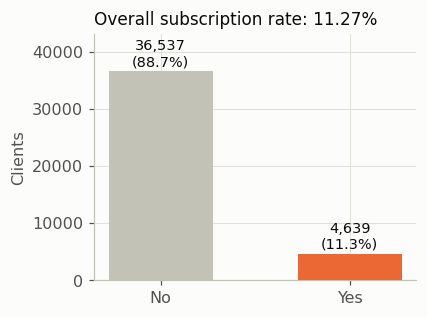

In [4]:
fig, ax = plt.subplots(figsize=(4, 3))
counts = df["y"].value_counts().reindex(["no", "yes"])
bars = ax.bar(["No", "Yes"], counts.values, color=[AXIS, ORANGE], width=0.55, zorder=3)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 400, f"{v:,}\n({v/len(df):.1%})",
             ha="center", va="bottom", fontsize=9.5)
ax.set_ylabel("Clients")
ax.set_title(f"Overall subscription rate: {OVERALL_RATE:.2%}", fontsize=11, loc="left")
ax.set_ylim(0, counts.max() * 1.18)
plt.tight_layout()
plt.show()

### 2.2 — Which job segments convert well enough to justify reallocating outreach toward them?

Call capacity is finite. If some job segments convert at 2–3x the base rate,
that's a direct case for weighting the call list toward them.

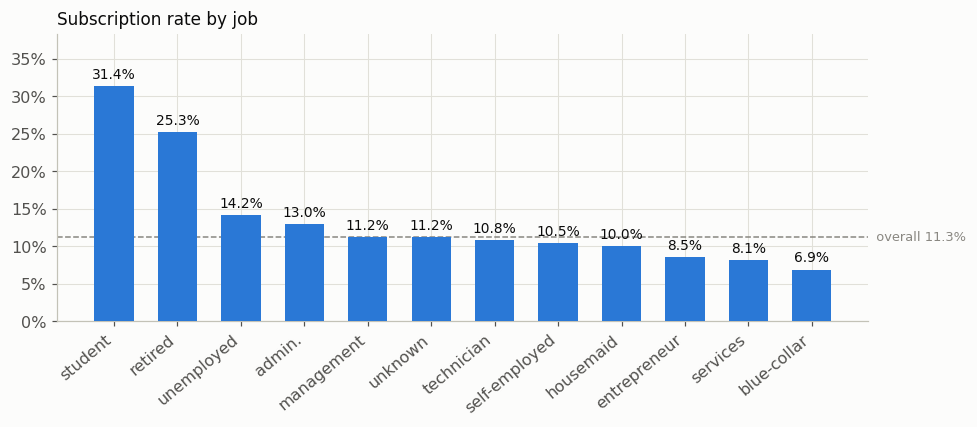

In [5]:
rates = df.groupby("job", observed=True)["y"].apply(lambda s: (s == "yes").mean()).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
bar_with_labels(ax, np.arange(len(rates)), rates.values, color=BLUE)
ax.set_xticks(np.arange(len(rates)))
ax.set_xticklabels(rates.index, rotation=40, ha="right")
pct_axis(ax)
ax.set_ylim(0, rates.max() * 1.22)
baseline_ref(ax, OVERALL_RATE, f"overall {OVERALL_RATE:.1%}")
ax.set_title("Subscription rate by job", loc="left", fontsize=11)
plt.tight_layout()
plt.show()

### 2.3 — Do a client's existing financial commitments signal lower receptiveness?

If clients already carrying a default flag or existing loans convert
meaningfully worse, that's a pre-call filter, not just a demographic fact.
Note the `unknown` bar in `default` — at 20.9% of rows it's large enough to
be its own segment, not noise.

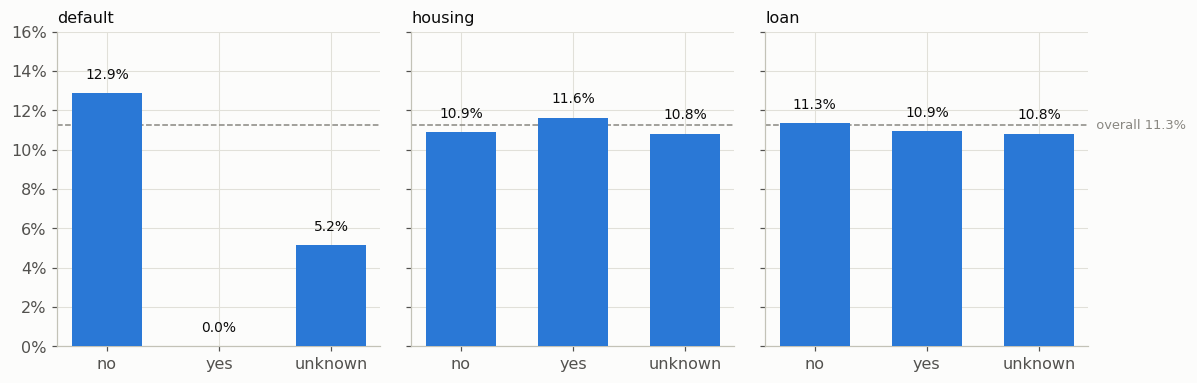

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharey=True)
for ax, col in zip(axes, ["default", "housing", "loan"]):
    order = ["no", "yes", "unknown"]
    order = [o for o in order if o in df[col].cat.categories]
    rates = df.groupby(col, observed=True)["y"].apply(lambda s: (s == "yes").mean()).reindex(order)
    bar_with_labels(ax, np.arange(len(rates)), rates.values, color=BLUE)
    ax.set_xticks(np.arange(len(rates)))
    ax.set_xticklabels(rates.index)
    ax.set_title(col, loc="left", fontsize=10.5)
    baseline_ref(ax, OVERALL_RATE, "" if ax is not axes[-1] else f"overall {OVERALL_RATE:.1%}")
pct_axis(axes[0])
axes[0].set_ylim(0, 0.16)
plt.tight_layout()
plt.show()

### 2.4 — Does marital status or education level justify segment-specific messaging?

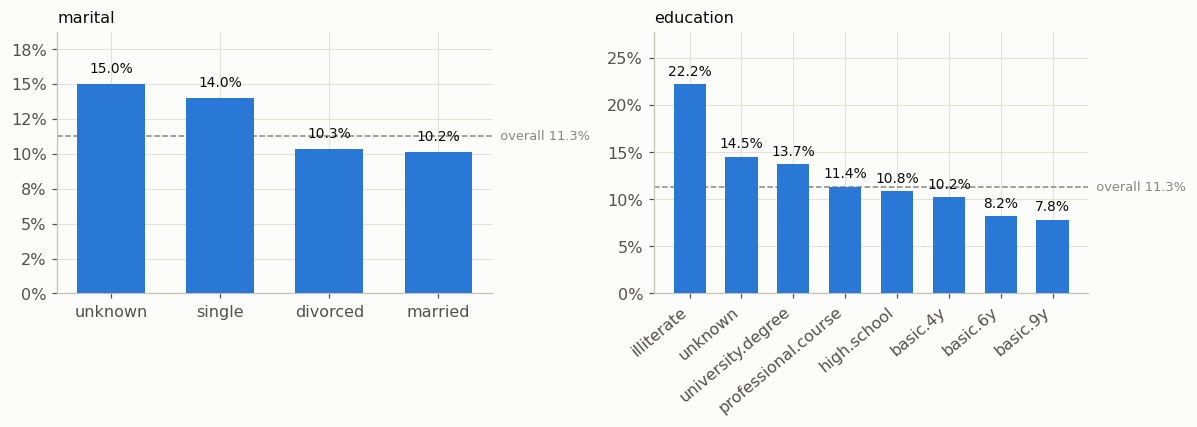

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

rates_m = df.groupby("marital", observed=True)["y"].apply(lambda s: (s == "yes").mean()).sort_values(ascending=False)
bar_with_labels(axes[0], np.arange(len(rates_m)), rates_m.values, color=BLUE)
axes[0].set_xticks(np.arange(len(rates_m))); axes[0].set_xticklabels(rates_m.index)
axes[0].set_title("marital", loc="left", fontsize=10.5)
pct_axis(axes[0]); axes[0].set_ylim(0, rates_m.max() * 1.25)
baseline_ref(axes[0], OVERALL_RATE, f"overall {OVERALL_RATE:.1%}")

rates_e = df.groupby("education", observed=True)["y"].apply(lambda s: (s == "yes").mean()).sort_values(ascending=False)
bar_with_labels(axes[1], np.arange(len(rates_e)), rates_e.values, color=BLUE)
axes[1].set_xticks(np.arange(len(rates_e))); axes[1].set_xticklabels(rates_e.index, rotation=40, ha="right")
axes[1].set_title("education", loc="left", fontsize=10.5)
pct_axis(axes[1]); axes[1].set_ylim(0, rates_e.max() * 1.25)
baseline_ref(axes[1], OVERALL_RATE, f"overall {OVERALL_RATE:.1%}")

plt.tight_layout()
plt.show()

### 2.5 — Is contact channel a lever we can pull, and does it actually matter?

**Caveat before reading this chart:** `contact` is confounded with time
period (data quality issue #6 above) — cellular contacts are concentrated in
later, more receptive months. Treat this as descriptive, not a "switch to
cellular" recommendation, until it's tested controlling for period.

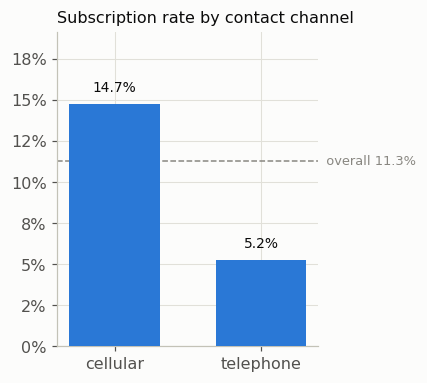

In [8]:
rates = df.groupby("contact", observed=True)["y"].apply(lambda s: (s == "yes").mean())

fig, ax = plt.subplots(figsize=(4, 3.6))
bar_with_labels(ax, np.arange(len(rates)), rates.values, color=BLUE)
ax.set_xticks(np.arange(len(rates))); ax.set_xticklabels(rates.index)
pct_axis(ax); ax.set_ylim(0, rates.max() * 1.3)
baseline_ref(ax, OVERALL_RATE, f"overall {OVERALL_RATE:.1%}")
ax.set_title("Subscription rate by contact channel", loc="left", fontsize=10.5)
plt.tight_layout()
plt.show()

### 2.6 — Should the outcome of a client's previous campaign gate whether we call them again?

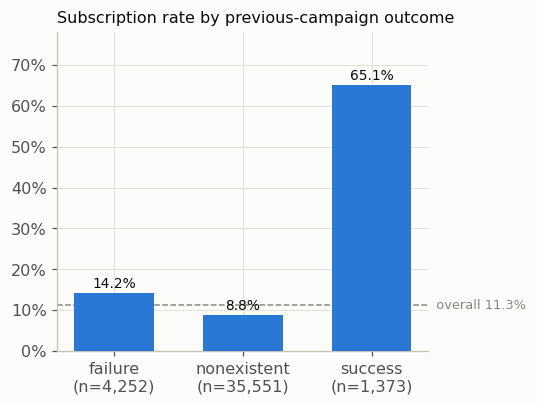

In [9]:
order = ["failure", "nonexistent", "success"]
rates = df.groupby("poutcome", observed=True)["y"].apply(lambda s: (s == "yes").mean()).reindex(order)
counts = df["poutcome"].value_counts().reindex(order)

fig, ax = plt.subplots(figsize=(5, 3.8))
bar_with_labels(ax, np.arange(len(rates)), rates.values, color=BLUE)
ax.set_xticks(np.arange(len(rates)))
ax.set_xticklabels([f"{i}\n(n={c:,})" for i, c in zip(order, counts.values)])
pct_axis(ax); ax.set_ylim(0, rates.max() * 1.2)
baseline_ref(ax, OVERALL_RATE, f"overall {OVERALL_RATE:.1%}")
ax.set_title("Subscription rate by previous-campaign outcome", loc="left", fontsize=10.5)
plt.tight_layout()
plt.show()

### 2.7 — Are some months structurally better, once we account for how many calls were actually made?

Raw rate-by-month is misleading on its own: May carries 13,769 contacts while
March carries only 546. A month with a high rate on a tiny sample is not the
same finding as a high rate on a large one — shown side by side so neither
reads in isolation.

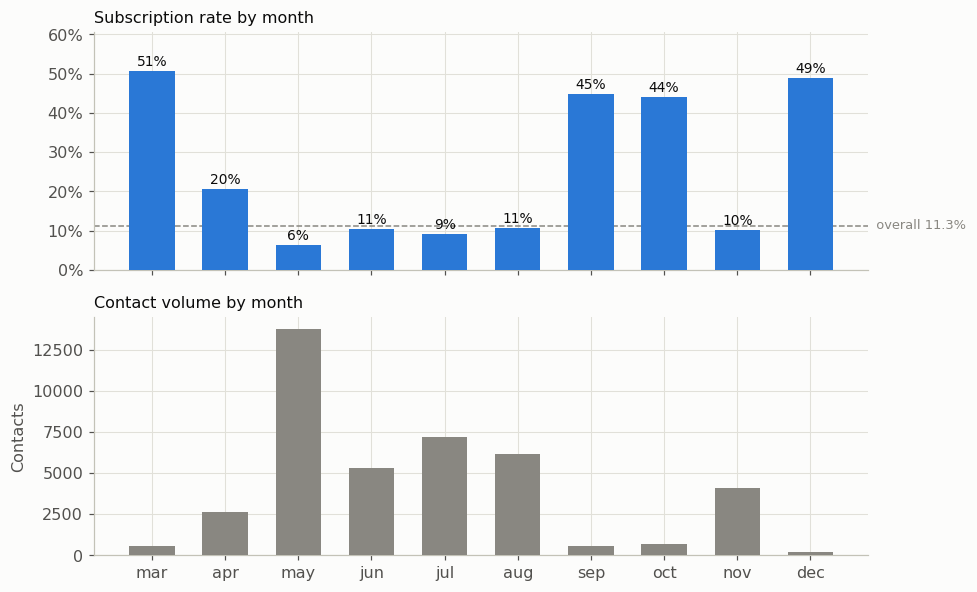

In [10]:
month_order = ["mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]
month_order = [m for m in month_order if m in df["month"].cat.categories]
rates = df.groupby("month", observed=True)["y"].apply(lambda s: (s == "yes").mean()).reindex(month_order)
counts = df["month"].value_counts().reindex(month_order)

fig, axes = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)
bar_with_labels(axes[0], np.arange(len(rates)), rates.values, color=BLUE, fmt="{:.0%}")
pct_axis(axes[0]); axes[0].set_ylim(0, rates.max() * 1.2)
baseline_ref(axes[0], OVERALL_RATE, f"overall {OVERALL_RATE:.1%}")
axes[0].set_title("Subscription rate by month", loc="left", fontsize=10.5)

axes[1].bar(np.arange(len(counts)), counts.values, color=MUTED, width=0.62, zorder=3)
axes[1].set_xticks(np.arange(len(counts))); axes[1].set_xticklabels(month_order)
axes[1].set_title("Contact volume by month", loc="left", fontsize=10.5)
axes[1].set_ylabel("Contacts")

plt.tight_layout()
plt.show()

### 2.8 — Does day of week matter enough to be worth scheduling around?

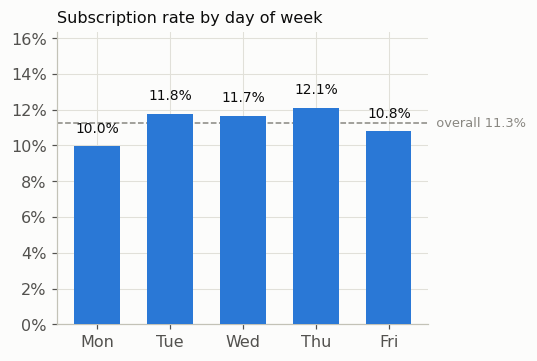

Range across days: 10.0% to 12.1% — weak effect relative to the segment gaps above.


In [11]:
order = ["mon","tue","wed","thu","fri"]
rates = df.groupby("day_of_week", observed=True)["y"].apply(lambda s: (s == "yes").mean()).reindex(order)

fig, ax = plt.subplots(figsize=(5, 3.4))
bar_with_labels(ax, np.arange(len(rates)), rates.values, color=BLUE)
ax.set_xticks(np.arange(len(rates))); ax.set_xticklabels(["Mon","Tue","Wed","Thu","Fri"])
pct_axis(ax); ax.set_ylim(0, rates.max() * 1.35)
baseline_ref(ax, OVERALL_RATE, f"overall {OVERALL_RATE:.1%}")
ax.set_title("Subscription rate by day of week", loc="left", fontsize=10.5)
plt.tight_layout()
plt.show()
print("Range across days:", f"{rates.min():.1%}", "to", f"{rates.max():.1%}",
      "— weak effect relative to the segment gaps above.")

## 3. Campaign contacts (`campaign`) vs outcome

### 3.1 — Is there a point where repeated calling within a campaign stops working, and where should we cap it?

`campaign` counts contacts to this client in this campaign, including the
current one. If conversion falls as this rises, every call past that point is
capacity spent for a worse-than-average return.

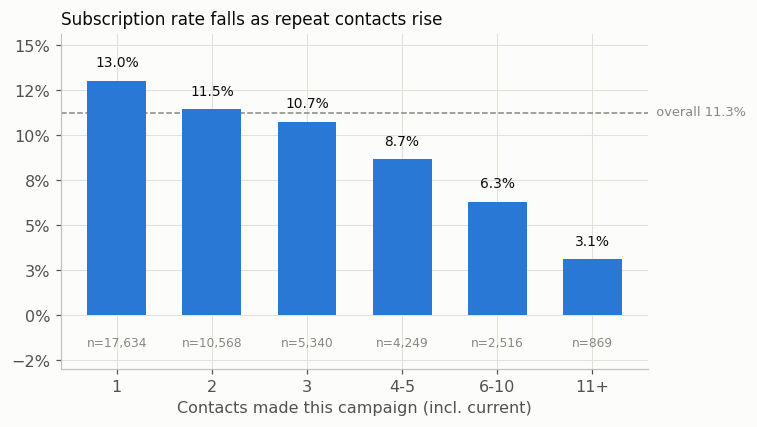

In [12]:
bins = [0, 1, 2, 3, 5, 10, 100]
labels = ["1", "2", "3", "4-5", "6-10", "11+"]
df["campaign_bucket"] = pd.cut(df["campaign"], bins=bins, labels=labels)

grp = df.groupby("campaign_bucket", observed=True)["y"].apply(lambda s: (s == "yes").mean())
counts = df["campaign_bucket"].value_counts().reindex(labels)

fig, ax = plt.subplots(figsize=(7, 4))
bars = bar_with_labels(ax, np.arange(len(grp)), grp.values, color=BLUE)
for i, c in enumerate(counts.values):
    ax.text(i, -0.012, f"n={c:,}", ha="center", va="top", fontsize=8, color=MUTED)
ax.set_xticks(np.arange(len(grp))); ax.set_xticklabels(labels)
ax.set_xlabel("Contacts made this campaign (incl. current)")
pct_axis(ax); ax.set_ylim(-0.03, grp.max() * 1.2)
baseline_ref(ax, OVERALL_RATE, f"overall {OVERALL_RATE:.1%}")
ax.set_title("Subscription rate falls as repeat contacts rise", loc="left", fontsize=11)
plt.tight_layout()
plt.show()

## 4. Prior-contact behavior (`pdays`, `previous`) — including the 999 sentinel

### 4.1 — Should previously-contacted clients be worked as a fundamentally different pool?

`pdays == 999` means "never contacted before a previous campaign" for 96.3%
of clients (data quality decision #3). We compare that group against the
3.7% with a real prior-contact gap, and check whether recency or frequency of
that prior contact adds anything on top of simply "were they contacted before."

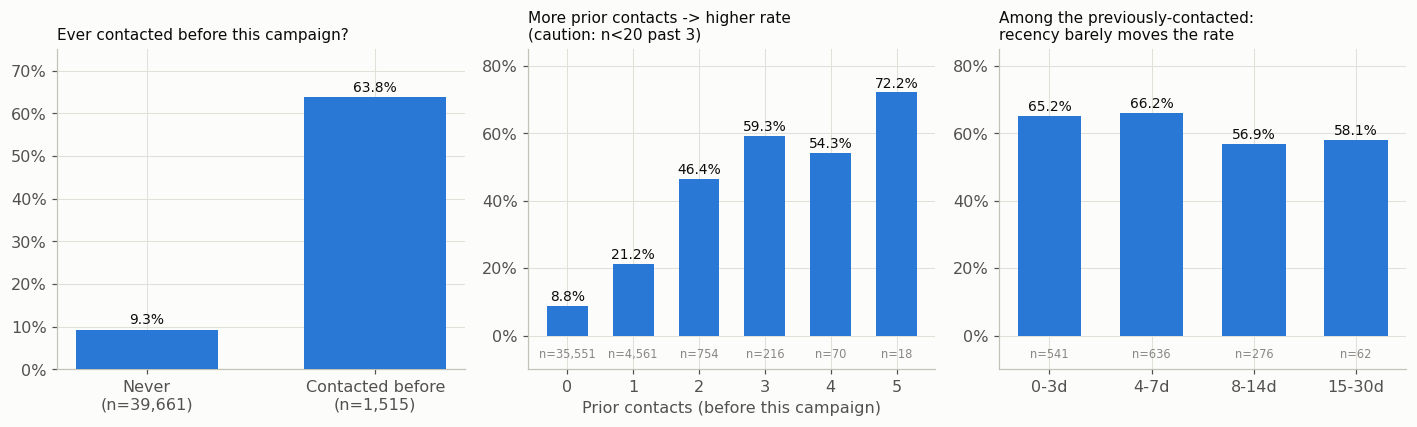

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# (a) contacted-before vs never
rates = df.groupby("was_contacted_before")["y"].apply(lambda s: (s == "yes").mean())
counts = df["was_contacted_before"].value_counts()
bar_with_labels(axes[0], [0, 1], [rates[False], rates[True]], color=BLUE)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels([f"Never\n(n={counts[False]:,})", f"Contacted before\n(n={counts[True]:,})"])
pct_axis(axes[0]); axes[0].set_ylim(0, 0.75)
axes[0].set_title("Ever contacted before this campaign?", loc="left", fontsize=10)

# (b) previous contact count (capped display at 5 — n<20 beyond that)
prev = df[df["previous"] <= 5].groupby("previous")["y"].apply(lambda s: (s == "yes").mean())
prev_n = df[df["previous"] <= 5]["previous"].value_counts().sort_index()
bar_with_labels(axes[1], prev.index, prev.values, color=BLUE)
for i, c in zip(prev.index, prev_n.values):
    axes[1].text(i, -0.04, f"n={c:,}", ha="center", va="top", fontsize=7.5, color=MUTED)
pct_axis(axes[1]); axes[1].set_ylim(-0.1, 0.85)
axes[1].set_xlabel("Prior contacts (before this campaign)")
axes[1].set_title("More prior contacts -> higher rate\n(caution: n<20 past 3)", loc="left", fontsize=10)

# (c) among the previously-contacted, does recency matter?
sub = df[df["was_contacted_before"]].copy()
sub["pdays_bucket"] = pd.cut(sub["pdays"], bins=[-1, 3, 7, 14, 30], labels=["0-3d", "4-7d", "8-14d", "15-30d"])
rec = sub.groupby("pdays_bucket", observed=True)["y"].apply(lambda s: (s == "yes").mean())
rec_n = sub["pdays_bucket"].value_counts().reindex(rec.index)
bar_with_labels(axes[2], np.arange(len(rec)), rec.values, color=BLUE)
for i, c in enumerate(rec_n.values):
    axes[2].text(i, -0.04, f"n={c:,}", ha="center", va="top", fontsize=7.5, color=MUTED)
axes[2].set_xticks(np.arange(len(rec))); axes[2].set_xticklabels(rec.index)
pct_axis(axes[2]); axes[2].set_ylim(-0.1, 0.85)
axes[2].set_title("Among the previously-contacted:\nrecency barely moves the rate", loc="left", fontsize=10)

plt.tight_layout()
plt.show()

## 5. Macro-economic conditions vs outcome, over time

### 5.1 — Does campaign success track the broader economic cycle, meaning outreach should flex with it rather than stay constant?

There's no year field (data quality decision #5), so we use **row order**
binned into 40 equal-sized chronological groups as the time axis — validated
above by the fact that `emp.var.rate` only changes at 11 points across the
whole file, in contiguous blocks.

Per the "no dual-axis" rule, the macro indicators and the conversion rate are
plotted as separate stacked panels sharing one x-axis, not overlaid on two
y-scales — a shared axis would force one of these series into a misleading
scale.

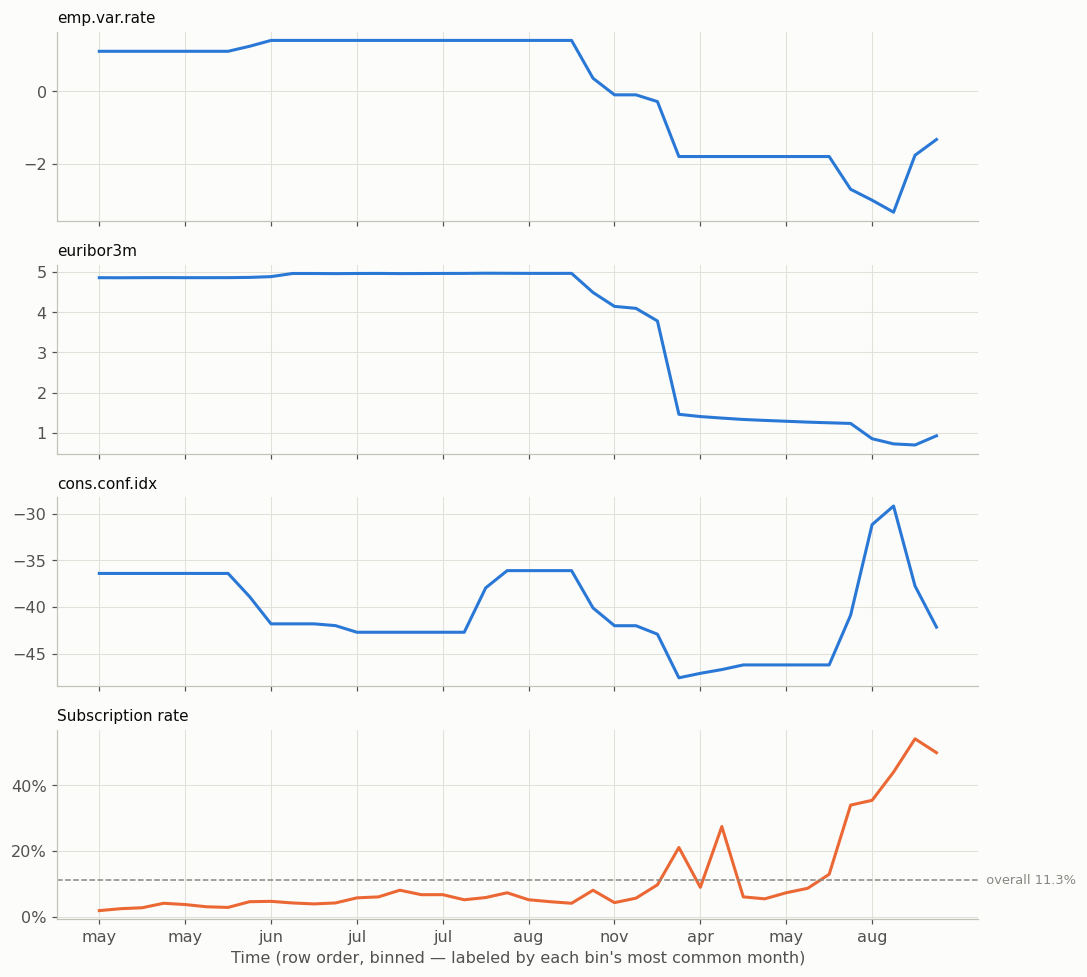

corr(emp.var.rate, y) = -0.298
corr(euribor3m, y) = -0.308
corr(cons.conf.idx, y) = +0.055


In [14]:
N_BINS = 40
df["time_bin"] = pd.cut(df["row_order"], bins=N_BINS, labels=False)

agg = df.groupby("time_bin").agg(
    emp_var_rate=("emp.var.rate", "mean"),
    euribor3m=("euribor3m", "mean"),
    cons_conf_idx=("cons.conf.idx", "mean"),
    rate=("y", lambda s: (s == "yes").mean()),
    dominant_month=("month", lambda s: s.mode().iloc[0]),
)

fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
panels = [
    ("emp_var_rate", "emp.var.rate", BLUE),
    ("euribor3m", "euribor3m", BLUE),
    ("cons_conf_idx", "cons.conf.idx", BLUE),
    ("rate", "Subscription rate", ORANGE),
]
for ax, (col, title, color) in zip(axes, panels):
    ax.plot(agg.index, agg[col], color=color, linewidth=2)
    ax.set_title(title, loc="left", fontsize=10)
    if col == "rate":
        pct_axis(ax)
        baseline_ref(ax, OVERALL_RATE, f"overall {OVERALL_RATE:.1%}")

tick_idx = list(range(0, N_BINS, 4))
axes[-1].set_xticks(tick_idx)
axes[-1].set_xticklabels(agg["dominant_month"].iloc[tick_idx], rotation=0)
axes[-1].set_xlabel("Time (row order, binned — labeled by each bin's most common month)")

plt.tight_layout()
plt.show()

for c in ["emp.var.rate", "euribor3m", "cons.conf.idx"]:
    corr = df[c].corr((df["y"] == "yes").astype(int))
    print(f"corr({c}, y) = {corr:+.3f}")

## 6. What this means for targeting

**1. A per-client contact cap would likely raise blended conversion, not lower it.**
Subscription rate falls from 13.0% at 1 contact to 3.1% at 11+ contacts within
the same campaign (§3.1) — well below the 11.3% baseline by the 4th attempt.
Since every one of those calls costs the same agent-minute, capping outreach
at roughly 3–4 attempts and redirecting the freed capacity to un-contacted
leads should raise the campaign's overall return, not just its efficiency.

**2. A "won-before" list is disproportionately valuable and small enough to work exhaustively.**
Clients with a successful previous campaign convert at 65.1% versus 8.8% for
clients with no previous campaign, and previously-contacted clients overall
convert at 63.8% versus 9.3% for never-contacted ones (§4.1, §2.6) — but this
group is only ~3.7% of the client base. That combination (high value, low
volume) means it should be a standing recontact list worked ahead of any
fresh cold segment, not folded into the general queue.

**3. Outreach capacity should flex with the macro cycle, and the channel-mix "finding" needs a controlled test before anyone acts on it.**
Conversion rate rises as `emp.var.rate` and `euribor3m` fall (§5.1, corr ≈
-0.30 to -0.35) — clients were structurally more receptive during the
downturn portion of this data than the expansion portion. That argues for
planning call volume/staffing against the economic cycle rather than a flat
schedule. It also means the apparent cellular-vs-telephone advantage (§2.5)
can't be trusted at face value: cellular contacts are concentrated in exactly
the same later, weaker-economy period, so the channel and the cycle are
confounded. Any channel-shift recommendation needs a period-controlled
comparison, not this raw split.